# Task1 LINEAR REGRESSION 

# CASE STUDY: FINANCIAL DATA ANALYSIS AND VISUALIZATION

202031201020041胡鸣桐 Victoria Mingtong Hu

Develop a linear regression model to predict the future values for APPLE’s 
stocks

* Date-Transaction or trading Date.

* Open-The first transaction price per share after the opening of each trading day.

* High-The highest price is a good selling price.

* Low-The lowest price is a good buying price. 

* Close-The weighted average trading volume price of all trades one minute before the last transaction.

* Volume-Refers to the number of transactions completed for a certain transaction within a time unit.

# Data cleaning

#### 1. Import Libraries

Start by importing these necessary libraries to work with the dataset and build the machine learning model. 

In [1]:
import pandas as pd
import quandl as qndl
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.metrics import mean_squared_error,r2_score,accuracy_score

#### 2. Load and Explore Data

Load the Stock dataset from the quandl and convert it into a DataFrame. Take a look at the dataset’s structure and understand its features and target variable. QUANDL library provides stock exchange data that can be used to predict the future values of the stocks. It provides us the data according to the stock symbols. 

Register on this website and get my personal API-KEY to access data from QUANDL databases

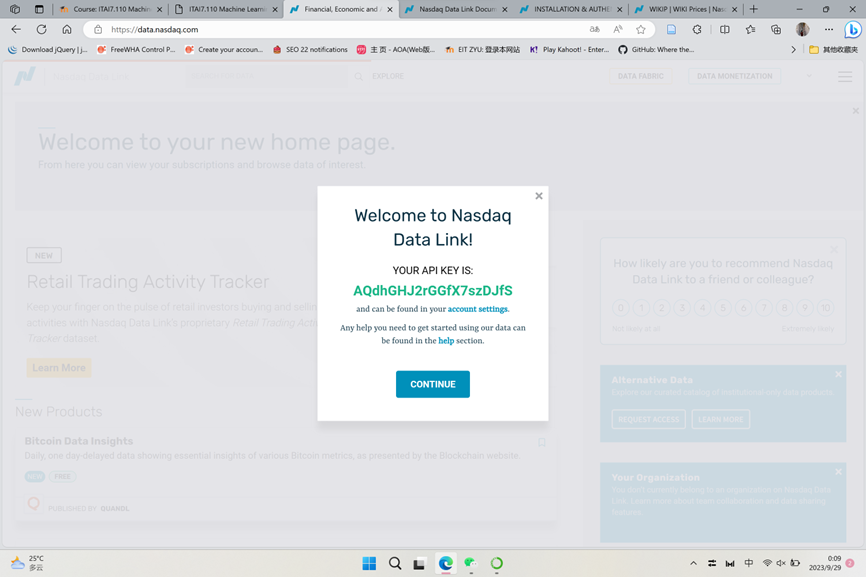

Using the get(SYMBOL) method, we can read data from WIKIP in QUANDL, where SYMBOL is a string that represents the stock symbol of a company.

In [2]:
symbol="WIKI/AAPL"
qndl.ApiConfig.api_key="AQdhGHJ2rGGfX7szDJfS"
df=qndl.get(symbol)
df.to_excel('StockData.xlsx')
df

,Open,High,Low,Close,Volume,Ex-Dividend,Split Ratio,Adj. Open,Adj. High,Adj. Low,Adj. Close,Adj. Volume
Date,,,,,,,,,,,,
1980-12-12,28.75,28.87,28.75,28.750,2093900.0,0.0,1.0,0.422706,0.424470,0.422706,0.422706,117258400.0
1980-12-15,27.38,27.38,27.25,27.250,785200.0,0.0,1.0,0.402563,0.402563,0.400652,0.400652,43971200.0
1980-12-16,25.37,25.37,25.25,25.250,472000.0,0.0,1.0,0.373010,0.373010,0.371246,0.371246,26432000.0
1980-12-17,25.87,26.00,25.87,25.870,385900.0,0.0,1.0,0.380362,0.382273,0.380362,0.380362,21610400.0
1980-12-18,26.63,26.75,26.63,26.630,327900.0,0.0,1.0,0.391536,0.393300,0.391536,0.391536,18362400.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2018-03-21,175.04,175.09,171.26,171.270,35247358.0,0.0,1.0,175.040000,175.090000,171.260000,171.270000,35247358.0
2018-03-22,170.00,172.68,168.60,168.845,41051076.0,0.0,1.0,170.000000,172.680000,168.600000,168.845000,41051076.0
2018-03-23,168.39,169.92,164.94,164.940,40248954.0,0.0,1.0,168.390000,169.920000,164.940000,164.940000,40248954.0


The data has a total of 9400 rows, with the index in time format and dates from December 12, 1980 to March 27, 2018. There are a total of 13 columns, with each column's name and data format listed and no missing values

In [3]:
data=pd.read_excel('StockData.xlsx')

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9400 entries, 0 to 9399
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         9400 non-null   datetime64[ns]
 1   Open         9400 non-null   float64       
 2   High         9400 non-null   float64       
 3   Low          9400 non-null   float64       
 4   Close        9400 non-null   float64       
 5   Volume       9400 non-null   int64         
 6   Ex-Dividend  9400 non-null   float64       
 7   Split Ratio  9400 non-null   int64         
 8   Adj. Open    9400 non-null   float64       
 9   Adj. High    9400 non-null   float64       
 10  Adj. Low     9400 non-null   float64       
 11  Adj. Close   9400 non-null   float64       
 12  Adj. Volume  9400 non-null   int64         
dtypes: datetime64[ns](1), float64(9), int64(3)
memory usage: 954.8 KB


#### 3. Data Preprocessing

In [4]:
data.describe()

,Open,High,Low,Close,Volume,Ex-Dividend,Split Ratio,Adj. Open,Adj. High,Adj. Low,Adj. Close,Adj. Volume
count,9400.000000,9400.000000,9400.000000,9400.000000,9.400000e+03,9400.000000,9400.000000,9400.000000,9400.000000,9400.000000,9400.000000,9.400000e+03
mean,101.233437,102.466958,99.896250,101.194472,1.198560e+07,0.003633,1.000957,21.571019,21.774929,21.351252,21.567664,8.860156e+07
std,135.169307,136.294005,133.829528,135.087350,1.662310e+07,0.088269,0.064409,39.272529,39.584888,38.942651,39.271266,8.704777e+07
min,11.120000,11.120000,11.000000,11.000000,4.471000e+03,0.000000,1.000000,0.163495,0.163495,0.161731,0.161731,2.503760e+05
25%,27.000000,27.500000,26.500000,27.000000,1.232075e+06,0.000000,1.000000,0.923453,0.940280,0.904096,0.922730,3.461080e+07
50%,43.750000,44.500000,43.000000,43.880000,3.776200e+06,0.000000,1.000000,1.437461,1.468272,1.410762,1.437445,6.069700e+07
75%,110.120000,111.755000,108.747500,110.060000,1.808312e+07,0.000000,1.000000,20.270182,20.565604,19.905845,20.294924,1.109031e+08
max,702.410000,705.070000,699.570000,702.100000,1.895606e+08,3.290000,7.000000,182.590000,183.500000,180.210000,181.720000,1.855410e+09


In [5]:
data.dropna(axis=0,inplace=True)
data.isna().sum()

Date           0
Open           0
High           0
Low            0
Close          0
Volume         0
Ex-Dividend    0
Split Ratio    0
Adj. Open      0
Adj. High      0
Adj. Low       0
Adj. Close     0
Adj. Volume    0
dtype: int64

In [6]:
data2= pd.DataFrame(pd.read_excel(r'StockData.xlsx'))
print(data2)

           Date    Open    High     Low    Close    Volume  Ex-Dividend  \
0    1980-12-12   28.75   28.87   28.75   28.750   2093900          0.0   
1    1980-12-15   27.38   27.38   27.25   27.250    785200          0.0   
2    1980-12-16   25.37   25.37   25.25   25.250    472000          0.0   
3    1980-12-17   25.87   26.00   25.87   25.870    385900          0.0   
4    1980-12-18   26.63   26.75   26.63   26.630    327900          0.0   
...         ...     ...     ...     ...      ...       ...          ...   
9395 2018-03-21  175.04  175.09  171.26  171.270  35247358          0.0   
9396 2018-03-22  170.00  172.68  168.60  168.845  41051076          0.0   
9397 2018-03-23  168.39  169.92  164.94  164.940  40248954          0.0   
9398 2018-03-26  168.07  173.10  166.44  172.770  36272617          0.0   
9399 2018-03-27  173.68  175.15  166.92  168.340  38962839          0.0   

      Split Ratio   Adj. Open   Adj. High    Adj. Low  Adj. Close  Adj. Volume  
0               1 

In [7]:
data2['Date'] = pd.to_datetime(data2['Date'])
data2=data2.set_index('Date')
data2.sort_values(by=['Date'],inplace=True,ascending=True)
data2.head()

,Open,High,Low,Close,Volume,Ex-Dividend,Split Ratio,Adj. Open,Adj. High,Adj. Low,Adj. Close,Adj. Volume
Date,,,,,,,,,,,,
1980-12-12,28.75,28.87,28.75,28.75,2093900,0.0,1,0.422706,0.424470,0.422706,0.422706,117258400
1980-12-15,27.38,27.38,27.25,27.25,785200,0.0,1,0.402563,0.402563,0.400652,0.400652,43971200
1980-12-16,25.37,25.37,25.25,25.25,472000,0.0,1,0.373010,0.373010,0.371246,0.371246,26432000
1980-12-17,25.87,26.00,25.87,25.87,385900,0.0,1,0.380362,0.382273,0.380362,0.380362,21610400
1980-12-18,26.63,26.75,26.63,26.63,327900,0.0,1,0.391536,0.393300,0.391536,0.391536,18362400


In [8]:
data2_unique=data2.drop_duplicates()

#### 4.Data Transformation

In [9]:
scaler=MinMaxScaler()
data2_normalized=scaler.fit_transform(data2)

In [10]:
scaler=StandardScaler()
data2_standardized=scaler.fit_transform(data2)

#### 5. Dealing with Outliers

In [11]:
z_scores=np.abs((data2-data2.mean())/data2.std())
z_scores.head()

,Open,High,Low,Close,Volume,Ex-Dividend,Split Ratio,Adj. Open,Adj. High,Adj. Low,Adj. Close,Adj. Volume
Date,,,,,,,,,,,,
1980-12-12,0.536242,0.539987,0.531618,0.536279,0.595058,0.041158,0.014865,0.538501,0.539359,0.537420,0.538433,0.329208
1980-12-15,0.546377,0.550919,0.542827,0.547383,0.673786,0.041158,0.014865,0.539014,0.539912,0.537986,0.538995,0.512711
1980-12-16,0.561248,0.565667,0.557771,0.562188,0.692627,0.041158,0.014865,0.539767,0.540659,0.538741,0.539744,0.714200
1980-12-17,0.557548,0.561044,0.553138,0.557598,0.697806,0.041158,0.014865,0.539580,0.540425,0.538507,0.539512,0.769591
1980-12-18,0.551926,0.555541,0.547460,0.551972,0.701295,0.041158,0.014865,0.539295,0.540146,0.538220,0.539227,0.806904


In [12]:
data2_no_outliers=data2[(z_scores<3).all(axis=1)]
Q1=data2.quantile(0.25)
Q3=data2.quantile(0.75)
IQR=Q3-Q1
data2_no_outliers_iqr=data2[~((data2<(Q1-1.5*IQR))|(data2>(Q3+1.5*IQR))).any(axis=1)]
print(data2_no_outliers_iqr.head())
print(len(data2[((data2<(Q1-1.5*IQR)) | (data2>(Q3+1.5*IQR))).any(axis =1)]))

             Open   High    Low  Close   Volume  Ex-Dividend  Split Ratio  \
Date                                                                        
1980-12-12  28.75  28.87  28.75  28.75  2093900          0.0            1   
1980-12-15  27.38  27.38  27.25  27.25   785200          0.0            1   
1980-12-16  25.37  25.37  25.25  25.25   472000          0.0            1   
1980-12-17  25.87  26.00  25.87  25.87   385900          0.0            1   
1980-12-18  26.63  26.75  26.63  26.63   327900          0.0            1   

            Adj. Open  Adj. High  Adj. Low  Adj. Close  Adj. Volume  
Date                                                                 
1980-12-12   0.422706   0.424470  0.422706    0.422706    117258400  
1980-12-15   0.402563   0.402563  0.400652    0.400652     43971200  
1980-12-16   0.373010   0.373010  0.371246    0.371246     26432000  
1980-12-17   0.380362   0.382273  0.380362    0.380362     21610400  
1980-12-18   0.391536   0.393300  0.3915

# Correlation Analysis

Pairplot represents the relationship between variables (linear or nonlinear, with or without significant correlation). On the diagonal, there is a histogram of each attribute, rather than a correlation graph between two different attributes. For the classification of 'Close', it was found in the pairplot after hue classification that the correlation characteristics between Close and variables can be seen from both the distribution map on the diagonal and the scatter plot after classification.

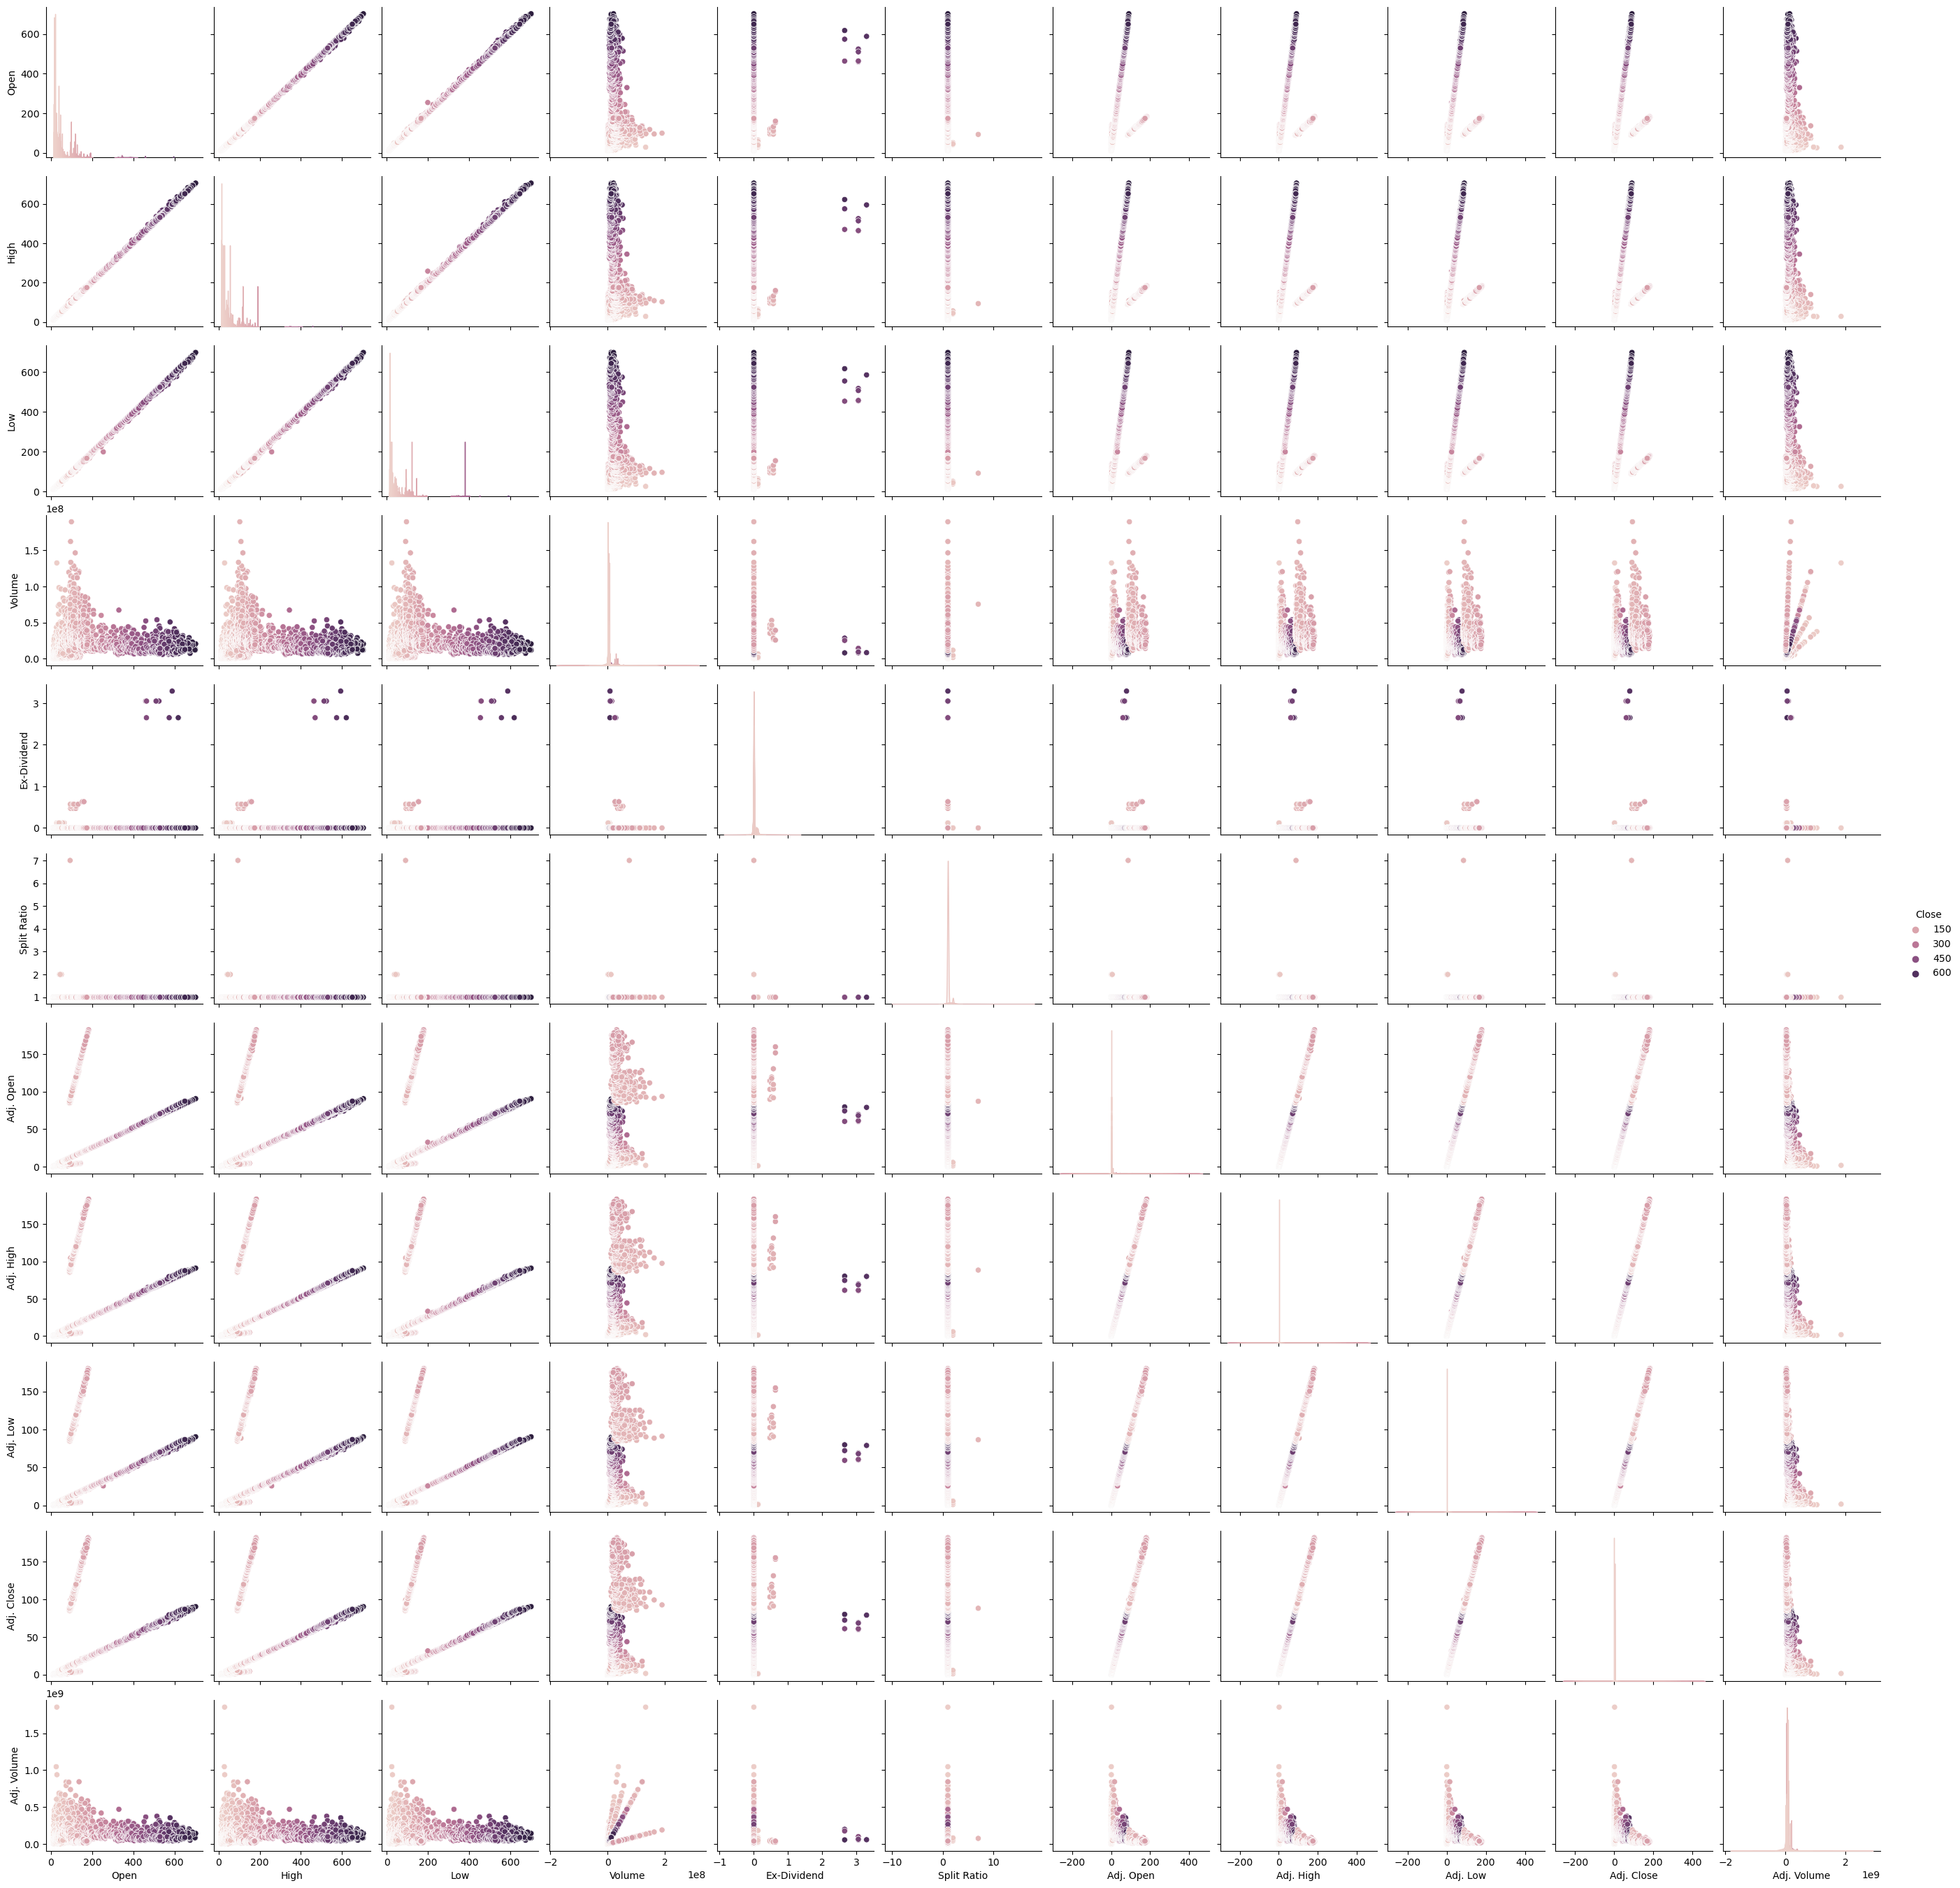

In [13]:
sns.pairplot(data=data,hue="Close")

Predicted column variables of data, storing the label name of the research object.

<Axes: >

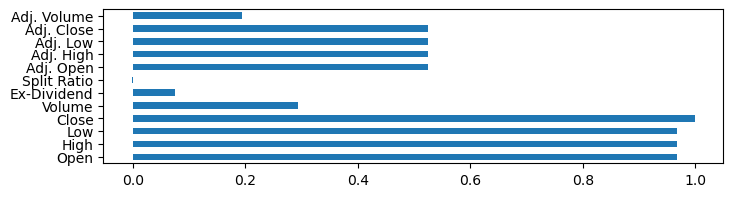

In [14]:
forecast_col='Close'
forecast=30
data2['Close']=data2[forecast_col].shift(-forecast)
data2.dropna(inplace=True)
data2.corr().loc['Close'].plot(kind='barh',figsize=(8,2))


The heatmap mainly displays the data relationships of two-dimensional data, with different sizes of values corresponding to different color shades.

<Figure size 2500x2000 with 0 Axes>

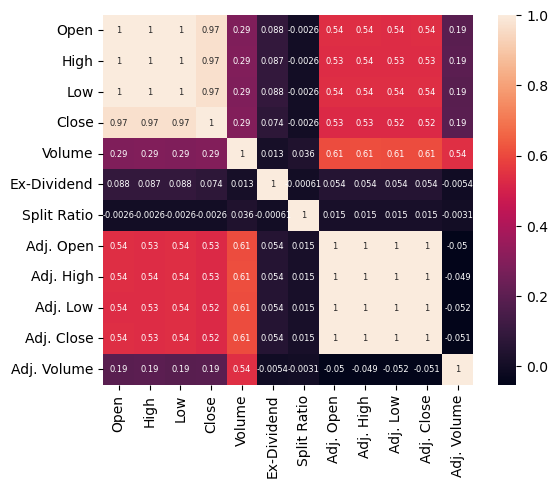

<Figure size 2500x2000 with 0 Axes>

In [15]:
sns.heatmap(data2.corr(),vmax=1.0,square=True,linecolor='white',annot=True,annot_kws={"fontsize":6})
plt.figure(figsize=(25,20))

We can see from the graph that there is a correlation between the closing price and other eigenvalues, with positive correlations such as Low, High, Open, Adj. Open, Adj. High, Adj. Low, Adj. Close, etc..
It can be concluded that there is not a strong correlation between the closing price and the total trading volume.

Treat the closing price as the target variable. Target Variable Chart

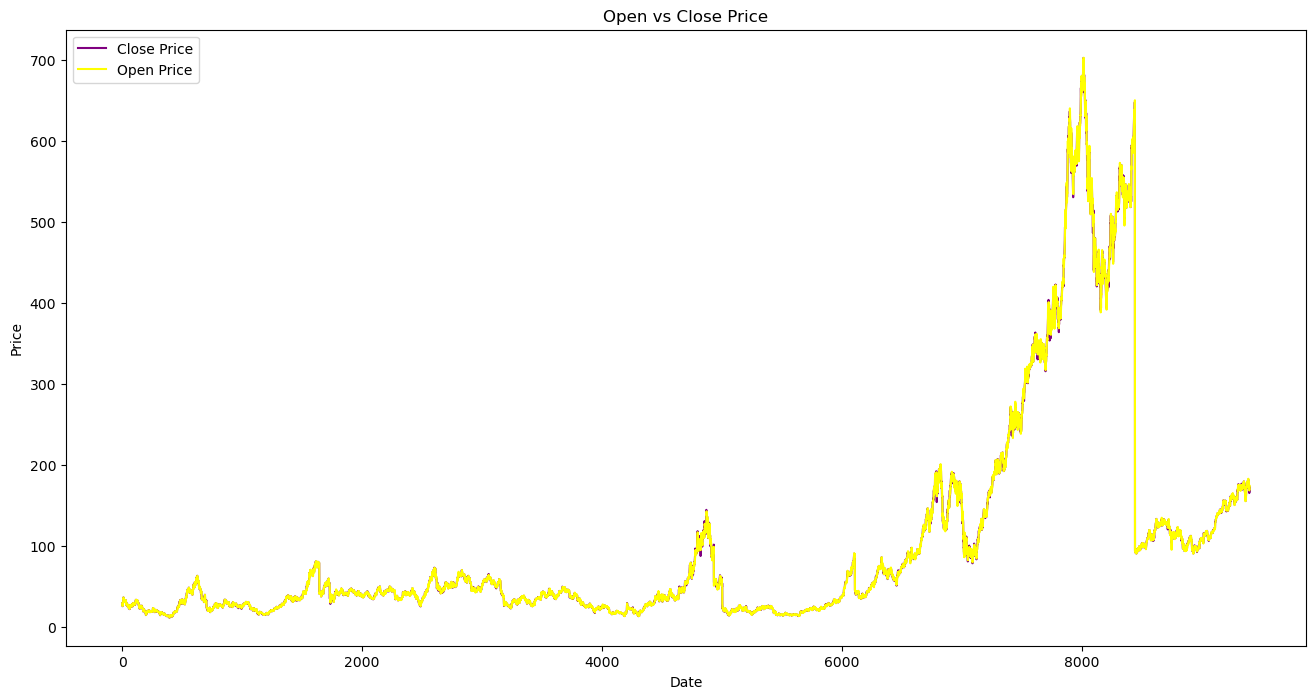

In [16]:
plt.figure(figsize=(16,8))
plt.plot(data['Close'],color='purple',label='Close Price')
plt.plot(data['Open'],color='yellow',label='Open Price')
plt.legend(loc='upper left')
plt.title('Open vs Close Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

Data visualization. Create a scatter plot to visualize the relationship between "X" and "y".

Visualize individual features for target variables.

<module 'matplotlib.pyplot' from 'D:\\Anaconda\\Lib\\site-packages\\matplotlib\\pyplot.py'>

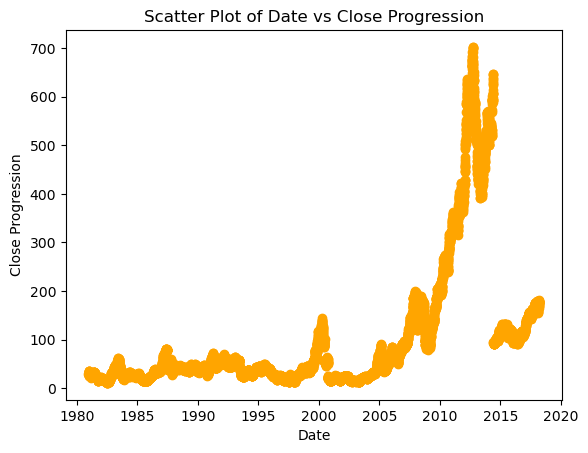

In [17]:
feature_name3="Date"
plt.scatter(data[feature_name3],data["Close"],color='orange')
plt.xlabel(feature_name3)
plt.ylabel("Close Progression")
plt.title(f"Scatter Plot of {feature_name3} vs Close Progression")
plt

<module 'matplotlib.pyplot' from 'D:\\Anaconda\\Lib\\site-packages\\matplotlib\\pyplot.py'>

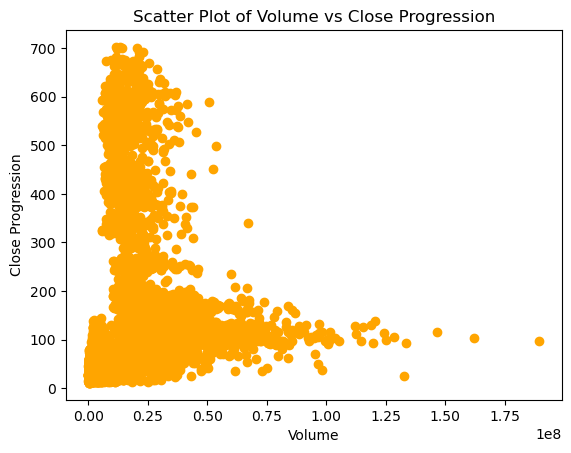

In [18]:
feature_name1="Volume"
plt.scatter(data[feature_name1],data["Close"],color='orange')
plt.xlabel(feature_name1)
plt.ylabel("Close Progression")
plt.title(f"Scatter Plot of {feature_name1} vs Close Progression")
plt

<module 'matplotlib.pyplot' from 'D:\\Anaconda\\Lib\\site-packages\\matplotlib\\pyplot.py'>

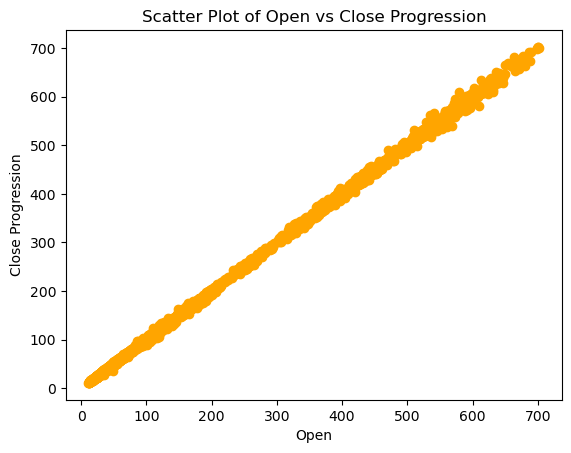

In [19]:
feature_name="Open"
plt.scatter(data[feature_name],data["Close"],color='orange')
plt.xlabel(feature_name)
plt.ylabel("Close Progression")
plt.title(f"Scatter Plot of {feature_name} vs Close Progression")
plt

We can see from the graph that there is a certain relationship between the opening and closing prices, and we will use linear regression prediction next.

Draw a time series chart of daily trading volume of stocks from 1980 to 2018 to observe the changes in stock trading volume over time.

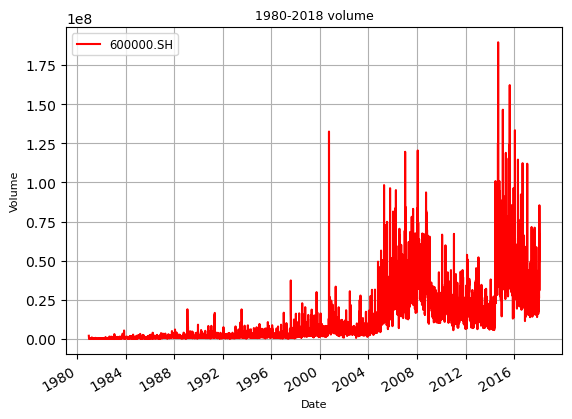

In [20]:
data2['Volume'].plot(grid=True,color='red',label='600000.SH')
plt.title('1980-2018 volume', fontsize='9')
plt.ylabel('Volume', fontsize='8')
plt.xlabel('Date', fontsize='8')
plt.legend(loc='best',fontsize='small')
plt.show()

Draw a time series chart of the daily closing price and daily trading volume of stocks from December 1980 to March 2018.

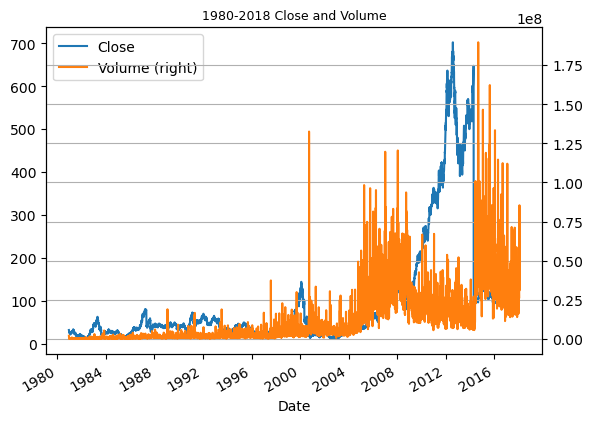

In [21]:
data2.index.name='Date'
data2.columns=['Open','High','Low','Close','Volume','Ex-Dividend','Split Ratio','Adj. Open','Adj. High','Adj. Low','Adj. Close','Adj. Volume']
data2=data2.loc['1980-12-12':'2018-03-27']
data2[['Close','Volume']].plot(secondary_y='Volume',grid=True)
plt.title('1980-2018 Close and Volume', fontsize='9')
plt.show()

# Create predicted values using RMSE

In [22]:
new_data = pd.DataFrame(index=range(0,len(data)),columns=['Date','Close'])

for i in range(0,len(data)):
    new_data['Date'][i] = data['Date'][i]
    new_data['Close'][i] = data['Close'][i]


In [23]:
train = new_data[:987]
test = new_data[987:]
print(new_data.shape, train.shape, test.shape)
print(train['Date'].min(), train['Date'].max(), test['Date'].min(), test['Date'].max())

(9400, 2) (987, 2) (8413, 2)
1980-12-12 00:00:00 1984-11-07 00:00:00 1984-11-08 00:00:00 2018-03-27 00:00:00


In [24]:
preds = []
for i in range(0,8413):
    a = train['Close'][len(train)-8413+i:].sum() + sum(preds)
    b = a/8413
    preds.append(b)

rms = np.sqrt(np.mean(np.power((np.array(test['Close'])-preds),2)))
rms

174.7407846460268

C:\Users\Mingtong Hu\AppData\Local\Temp\ipykernel_8536\3769200707.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Predictions'] = 0
C:\Users\Mingtong Hu\AppData\Local\Temp\ipykernel_8536\3769200707.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Predictions'] = preds


<Axes: >

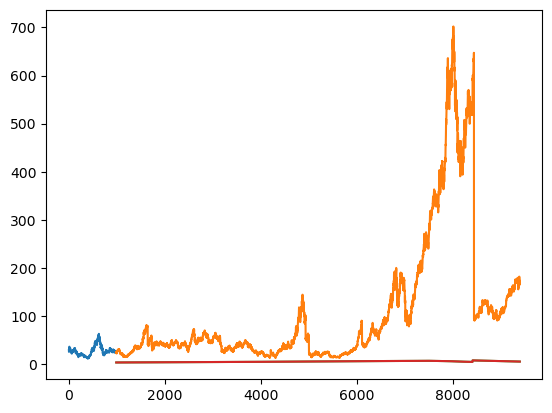

In [25]:
test['Predictions'] = 0
test['Predictions'] = preds

plt.plot(train['Close'])
plt.plot(test[['Close','Predictions']])
test['Predictions'].plot()

Split the data into elements (X) and target variables (y) to preprocess the data, and split the data into training and testing sets.Split the data into training and testing sets using a 70-30 split ratio.

In [26]:
X=data2.drop("Close",axis=1)
y=data2["Close"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

Evaluate the trained model’s performance by predicting on the scaled test data and calculating the accuracy. The accuracy is 0.9426830340262243.

Create an instance of the linear regression model.

In [27]:
lr_model=LinearRegression()
lr_model.fit(X_train,y_train)
lr_predictions=lr_model.predict(X_test)
accuracy = lr_model.score(X_test,y_test)
print("Accuracy:",accuracy);
lr_rmse=np.sqrt(mean_squared_error(y_test,lr_predictions))
print("Linear Regression RMSE :",lr_rmse)

Accuracy: 0.9426830340262243
Linear Regression RMSE : 31.65058445718413


In [28]:
rms = np.sqrt(np.mean(np.power((np.array(y_test)-np.array(lr_predictions)),2)))
rms

31.65058445718413

The RMSE value is 31.65058445718413, which can be considered as an average difference of 31.65058445718413 between the regression effect and the true value. The smaller the RMSE value, the greater its significance.

<module 'matplotlib.pyplot' from 'D:\\Anaconda\\Lib\\site-packages\\matplotlib\\pyplot.py'>

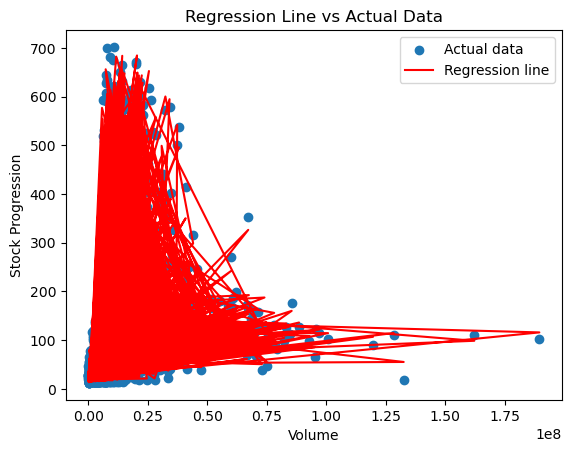

In [29]:
y_pred=lr_model.predict(X_test)
plt.scatter(X_test[feature_name1],y_test,label="Actual data")
plt.plot(X_test[feature_name1],y_pred,color="red",label="Regression line")
plt.xlabel(feature_name1)
plt.ylabel("Stock Progression")
plt.title("Regression Line vs Actual Data")
plt.legend()
plt

<module 'matplotlib.pyplot' from 'D:\\Anaconda\\Lib\\site-packages\\matplotlib\\pyplot.py'>

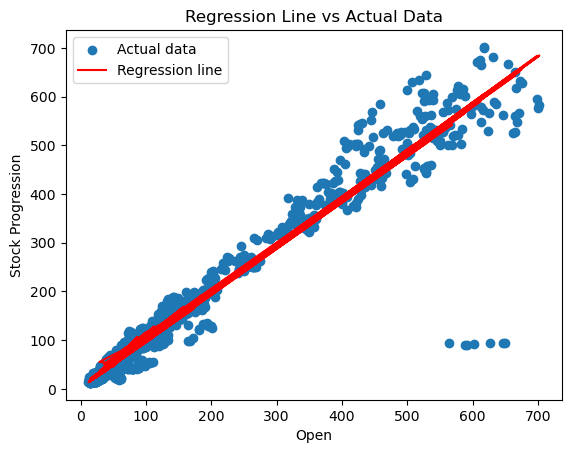

In [30]:
y1_pred=lr_model.predict(X_test)
plt.scatter(X_test[feature_name],y_test,label="Actual data")
plt.plot(X_test[feature_name],y_pred,color="red",label="Regression line")
plt.xlabel(feature_name)
plt.ylabel("Stock Progression")
plt.title("Regression Line vs Actual Data")
plt.legend()
plt

Make predictions using the test data. Calculate Mean Squared Error (MSE) and R- squared score

In [31]:
y_pred=lr_model.predict(X_test)

mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

print ("Mean Squared Error:",mse)
print ("R-squared Score:",r2)

Mean Squared Error: 1001.7594964813456
R-squared Score: 0.9426830340262243


R squared, Coefficent of determination.The R-squared Score value is less than or equal to 1, and the larger the R-squared, the better the fitting effect of the model. We obtained a value of 0.94268303402243 for R2, indicating that the model is good.

MSE represents the average of the sum of squares of the deviations between the predicted value and the true value. The results show that MSE is relatively large.

In [32]:
coefficients=lr_model.coef_
intercept=lr_model.intercept_

print("Coefficients:",coefficients )
print("Intercept:",intercept )


Coefficients: [ 1.03789970e+00 -4.30050270e-01  3.64484810e-01  1.89617712e-07
  1.35376926e+00 -1.89910822e+00  1.99210141e+00 -4.31587508e+00
 -1.90888043e+00  4.22303568e+00  1.16125784e-09]
Intercept: 4.401129082977306


A positive coefficient indicates a positive correlation between the independent variable and the dependent variable, a negative coefficient indicates a negative correlation between the independent variable and the dependent variable, and a zero coefficient indicates no significant correlation between the independent variable and the dependent variable.

Use standard scalers to standardize features

In [33]:
new_data=pd.DataFrame ({
'Open':[26.63,26.63,26.77],
'High':[26.75,26.55,25.79],
'Low':[26.63,25.53,26.72],
'Volume':[385900.0,376900.0,384560.0],
'Ex-Dividend':[0.0,0.0,0.0],
'Split Ratio':[1.0,1.0,1.0],
'Adj. Open': [0.422706,0.425706,0.422721],
'Adj. High': [0.424470,0.422706,0.432706],
'Adj. Low': [0.422706,0.452706,0.422732],
'Adj. Close':[0.422706,0.434706,0.432706],
'Adj. Volume':[43971200.0,26432000.0,36432000.0]
#'label':[0,0,0]
})
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

new_data_scaled=scaler.transform(new_data)
new_data_scaled=pd.DataFrame(new_data)
predictions=lr_model.predict(new_data_scaled)
print(f'Predictions:{ predictions }')

Predictions:[28.45623217 28.12623437 29.04484604]


The predicted values are 28.45623217, 28.12623437, and 29.04484604.

fit_ Intercept: Intercept, default to True, optional. When fit_ When intercept=False, it means there is no need for an intercept.

In [34]:
lr_model2=LinearRegression(fit_intercept=False)
lr_model2.fit(X_train,y_train)

lr_predictions2=lr_model2.predict(X_test)
lr_rmse2=np.sqrt(mean_squared_error(y_test,lr_predictions2))
print(" Linear Regression RMSE2 :",lr_rmse2)

 Linear Regression RMSE2 : 31.651729724216413


In [35]:
y_pred=lr_model2.predict(X_test)
mse2=mean_squared_error(y_test,y_pred)
r_2=r2_score(y_test,y_pred)
print ("Mean Squared Error:",mse2)
print ("R-squared Score:",r_2)

Mean Squared Error: 1001.8319945348447
R-squared Score: 0.9426788859562732


In [36]:
coefficients2=lr_model2.coef_
intercept2=lr_model2.intercept_

print("Coefficients:",coefficients2)
print("Intercept:",intercept2)


Coefficients: [ 1.03712916e+00 -4.31590073e-01  3.66810627e-01  1.85857346e-07
  1.35796539e+00  2.42889453e+00  1.96388704e+00 -4.25271245e+00
 -1.87878239e+00  4.15902154e+00  1.88839429e-09]
Intercept: 0.0
